# EDA

This first part focuses on data exploration and manipulation.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matchms.importing import load_from_json
import pickle

In [ ]:
# filename = "ALL_GNPS_20200511.json"
# spectra = load_from_json(f"src/data/{filename}")

# list_spectra = list(spectra)
# print(f"Number of spectra: {len(list_spectra)}")

# with open("src/data/gnps_spectra.pkl", "wb") as f:
#     pickle.dump(list_spectra, f)

In [17]:
with open("src/data/gnps_spectra.pkl", "rb") as f:
    spectra = pickle.load(f)

In [28]:
for spectrum in spectra[:5]:
  print(f"m/z range: {spectrum.peaks.mz.min()} - {spectrum.peaks.mz.max()}")

m/z range: 289.286377 - 982.221924
m/z range: 278.049927 - 940.88324
m/z range: 128.838745 - 455.885986
m/z range: 343.896484 - 546.972168
m/z range: 101.015465 - 1097.665161


### Different molecules have different m/z range

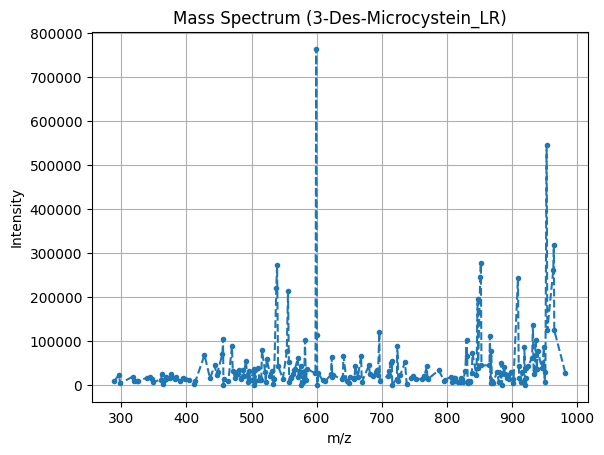

In [41]:
plt.plot(spectra[0].peaks.mz, spectra[0].peaks.intensities, '--.')
plt.xlabel("m/z")
plt.ylabel("Intensity")
plt.title(f"Mass Spectrum ({spectra[0].metadata.get('compound_name', 'Unknown')})")
plt.grid()
plt.show()

### To use Earth Mover Distance, normalization is needed

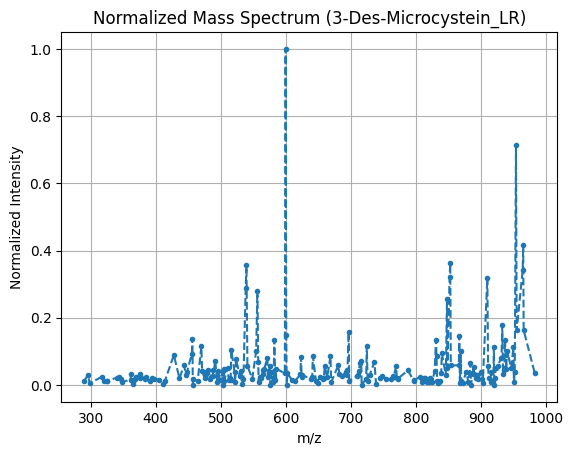

In [42]:
# normalize intensities to [0, 1]
normalized_intensities = spectra[0].peaks.intensities / np.max(spectra[0].peaks.intensities)
plt.plot(spectra[0].peaks.mz, normalized_intensities, '--.')
plt.xlabel("m/z")
plt.ylabel("Normalized Intensity")
plt.title(f"Normalized Mass Spectrum ({spectra[0].metadata.get('compound_name', 'Unknown')})")
plt.grid()
plt.show()

### Now we can try to visually compare intensities

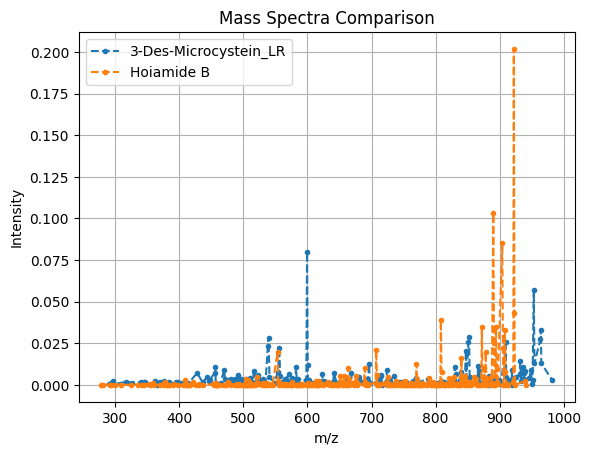

In [ ]:
# normalize to probability distributions and compare
# assuming we want to compare the shape of the spectra rather than absolute intensities

normalized1 = spectra[0].peaks.intensities / np.sum(spectra[0].peaks.intensities)
normalized2 = spectra[1].peaks.intensities / np.sum(spectra[1].peaks.intensities)
plt.plot(spectra[0].peaks.mz, normalized1, '--.', label=f"{spectra[0].metadata.get('compound_name', 'Unknown')}")
plt.plot(spectra[1].peaks.mz, normalized2, '--.', label=f"{spectra[1].metadata.get('compound_name', 'Unknown')}")
plt.xlabel("m/z")
plt.ylabel("Intensity")
plt.title("Mass Spectra Comparison")
plt.legend()
plt.grid()
plt.show()

In [49]:
# # check if sum of normalized intensities is 1
# print(f"Sum of normalized intensities (spectrum 1): {np.sum(normalized1)}")
# print(f"Sum of normalized intensities (spectrum 2): {np.sum(normalized2)}")

### When moving from this example to a larger scale comparison, an additional filtering and cleaning pipeline will be needed

In [77]:
# compute cosine similarity between the two spectra

from matchms import calculate_scores
from matchms.similarity import CosineGreedy
similarity_measure = CosineGreedy(tolerance=0.005)

spectrums = [spectra[0], spectra[1]]

scores = calculate_scores(spectrums, spectrums, similarity_measure, is_symmetric=True)

Calculating similarities: 100%|█████████████████| 2/2 [00:00<00:00, 1534.69it/s]


In [78]:
scores.score_names

('CosineGreedy_score', 'CosineGreedy_matches')

In [81]:
scores.scores['CosineGreedy_score']

(array([0, 0, 1, 1]),
 array([0, 1, 0, 1]),
 array([1.00000000e+00, 3.47802614e-06, 3.47802614e-06, 1.00000000e+00]))

In [82]:
row, col, val = scores.scores['CosineGreedy_score']

n = len(spectrums)
S = np.zeros((n, n))

S[row, col] = val

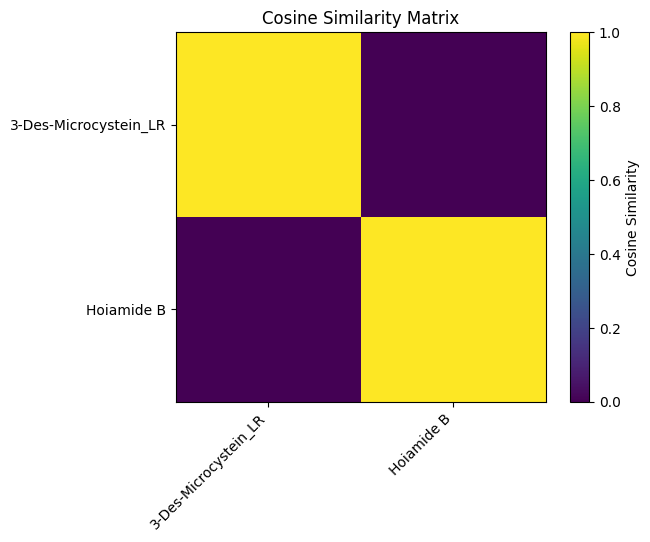

In [85]:
plt.imshow(S, cmap='viridis', vmin=0, vmax=1)
plt.title("Cosine Similarity Matrix")
plt.xticks(ticks=np.arange(n), labels=[s.metadata.get('compound_name', 'Unknown') for s in spectrums], rotation=45, ha='right')
plt.yticks(ticks=np.arange(n), labels=[s.metadata.get('compound_name', 'Unknown') for s in spectrums])
plt.colorbar(label='Cosine Similarity')
plt.show()